# Project work 1, Mattia Franchi

This notebook analyzes Norwegian reservoir data with Python and Pandas. I started by loading the `reservoirs.CSV` file containing weekly information on reservoir filling levels, capacity, and geographical coverage. After the data is imported, the column names are cleaned and translated into English to make the dataset easier to interpret and work with. Key variables such as date, region, year, week, storage capacity, current filling level, and weekly change are standardized for further analysis.

Once the data is organized, the notebook explores its structure and summarizes the main numerical statistics. It checks the DataFrame format, identifies variable types, and looks at general distribution patterns and missing values. This preliminary review helps determine whether the dataset is suitable for visualization and comparison.

The main focus of the notebook is then on time-series analysis. Individual numeric variables are plotted to identify long-term trends and seasonal patterns. Because the indicators use different units and scales, I have applied Min-Max normalisation so that multiple metrics can be compared on the same chart without distortion. This, for me,  makes it easier to understand how reservoir levels and related indicators evolve over time.

The final part of the notebook extends the analysis into a Streamlit dashboard. It includes the following parts:
1) `app.py` => This file is the app’s entry point.
* it sets the global configuration with st.set_page_config(...)
* defines the dashboard title
* displays the initial home page
* invites the user to use the sidebar to navigate between sections

2) `2_Table.py` => This page is responsible for displaying the data in tabular form.
* reads the CSV file
* renames the columns in English
* converts the date column to datetime
* uses @st.cache_data to avoid reloading the file on every page refresh
Then it creates a table where:
* each metric is a row
* the “First Month Trend” column contains a mini time series
* st.dataframe(...) with LineChartColumn displays inline charts

3) `3_Plot.py` => This page is the most interactive part of the app.
* the user can select one or more metrics using st.multiselect
* can choose a time range with st.slider
* the data are filtered according to the selected time window
* then a line chart is created with st.line_chart(...)

4) `4_Extra.py` => This page was created to show something more about the date of the reservoirs
* it takes the latest available date
* filters the data by area type (area_type)
* allows the user to choose a region using st.selectbox
* then displays data for each area in a horizontal grid using st.columns(5)
* uses st.metric(...) to show KPIs such as:
    -   filling level
    -   change compared with the previous week

At the end, I also changed a bit of the template to make it look different from the standard.


## Useful Links
- Github:
- Streamlit:
- Video:

## Use of AI
During the development of this project, Artificial Intelligence was utilized as a supportive tool to enhance the overall workflow. Specifically, Gemini was instrumental in debugging the code, resolving Jupyter Notebook kernel memory disconnections, and fixing Matplotlib rendering warnings. 

Additionally, Copilot assisted me in refining the English phrasing of the technical documentation, ensuring that the explanations of the code and the architectural choices were clear, professional, and well-structured.

### Read the reservoirs.csv file using Pandas (located in D2Dbook/data).


In [6]:
import pandas as pd 

# Reading the CSV file into a DataFrame
df = pd.read_csv(r"C:\Users\matti\Desktop\ind320-m4tti4fr4nchi\data\reservoirs.csv")
#Print the first 5 rows of the DataFrame
df.head()


,dato_Id,omrType,omrnr,iso_aar,iso_uke,fyllingsgrad,kapasitet_TWh,fylling_TWh,neste_Publiseringsdato,fyllingsgrad_forrige_uke,endring_fyllingsgrad
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,0001-01-01T00:00:00,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25T13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,0001-01-01T00:00:00,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,0001-01-01T00:00:00,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,0001-01-01T00:00:00,0.311122,-0.010301


### Rename headers to English and understandable


In [7]:
# Define a dictionary to map the original Norwegian column names to English
traduzione = {
    'dato_Id': 'date',
    'omrType': 'area_type',
    'omrnr': 'area_number',
    'iso_aar': 'year',
    'iso_uke': 'week',
    'fyllingsgrad': 'filling_rate',
    'kapasitet_TWh': 'capacity_twh',
    'fylling_TWh': 'filling_twh',
    'neste_Publiseringsdato': 'next_publish_date',
    'fyllingsgrad_forrige_uke': 'filling_rate_last_week',
    'endring_fyllingsgrad': 'filling_rate_change'
}

#apply the new column names to the dataframe
df = df.rename(columns=traduzione)

#print the first few rows of the dataframe to verify the changes
df.head()

,date,area_type,area_number,year,week,filling_rate,capacity_twh,filling_twh,next_publish_date,filling_rate_last_week,filling_rate_change
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,0001-01-01T00:00:00,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25T13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,0001-01-01T00:00:00,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,0001-01-01T00:00:00,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,0001-01-01T00:00:00,0.311122,-0.010301


### Print its contents in a relevant way
Printing the dataset structure and a statistical summary to understand data types, missing values, and the general distribution of the numerical metrics.

In [8]:
df.info()
df.describe().round(2).T #Rounded to 2 decimal places and transposed for better readability

<class 'pandas.DataFrame'>
RangeIndex: 14877 entries, 0 to 14876
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   date                    14877 non-null  str    
 1   area_type               14877 non-null  str    
 2   area_number             14877 non-null  int64  
 3   year                    14877 non-null  int64  
 4   week                    14877 non-null  int64  
 5   filling_rate            14877 non-null  float64
 6   capacity_twh            14877 non-null  float64
 7   filling_twh             14877 non-null  float64
 8   next_publish_date       14877 non-null  str    
 9   filling_rate_last_week  14877 non-null  float64
 10  filling_rate_change     14877 non-null  float64
dtypes: float64(5), int64(3), str(3)
memory usage: 1.7 MB


,count,mean,std,min,25%,50%,75%,max
area_number,14877.0,2.33,1.49,0.00,1.00,2.00,3.00,5.00
year,14877.0,2010.35,9.15,1995.00,2002.00,2010.00,2018.00,2026.00
week,14877.0,26.41,15.02,1.00,13.00,26.00,39.00,53.00
filling_rate,14877.0,0.62,0.21,0.06,0.46,0.65,0.80,1.02
capacity_twh,14877.0,29.15,22.74,6.00,17.39,23.24,34.04,87.44
filling_twh,14877.0,18.14,15.97,0.33,7.32,14.50,22.20,84.54
filling_rate_last_week,14877.0,0.62,0.21,0.06,0.46,0.65,0.80,1.02
filling_rate_change,14877.0,-0.00,0.03,-0.24,-0.02,-0.01,0.02,0.34


### Plot each column separately
Plotting each numeric column separately over time to identify distinct patterns, seasonalities, and overall trends across the dataset.

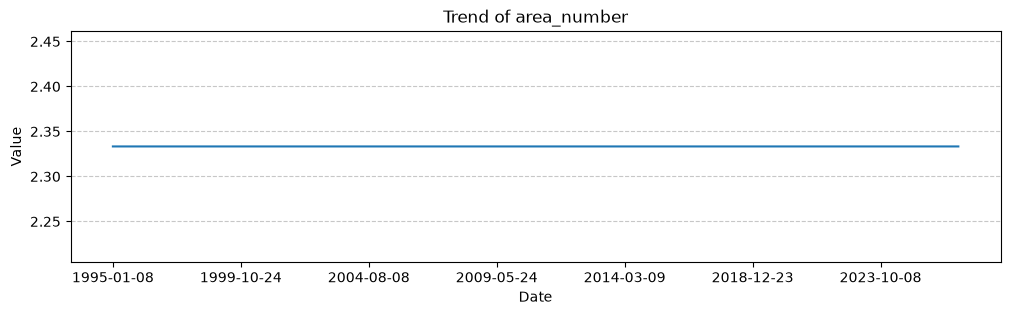

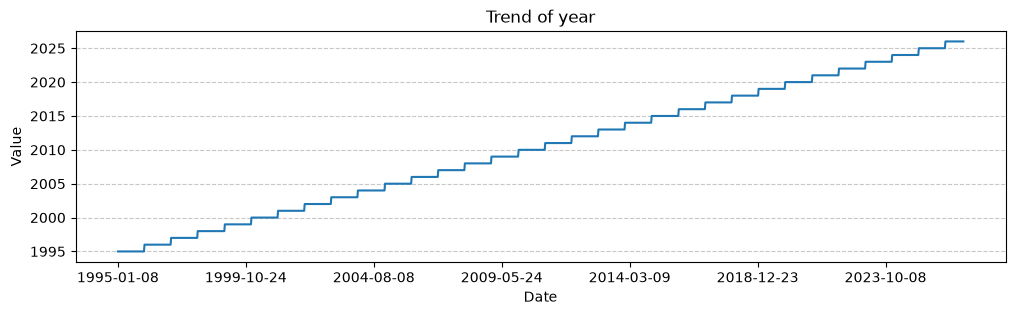

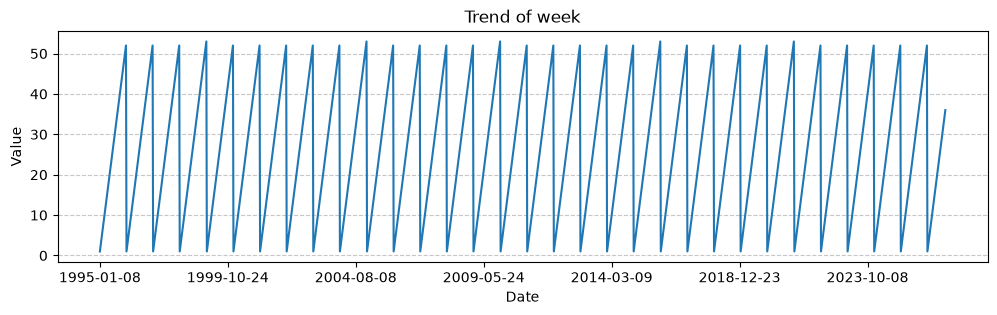

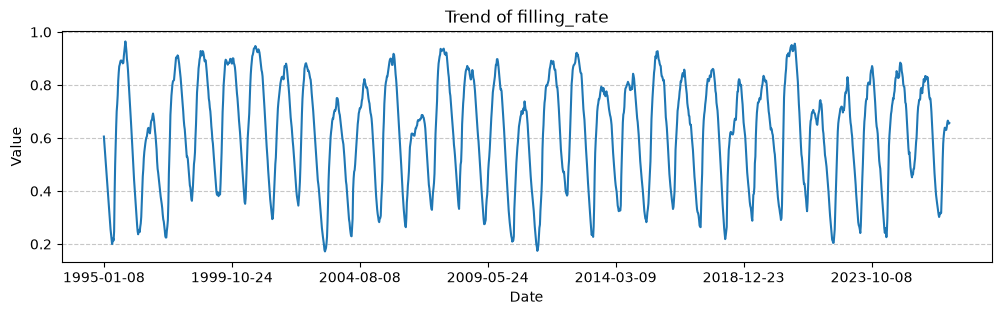

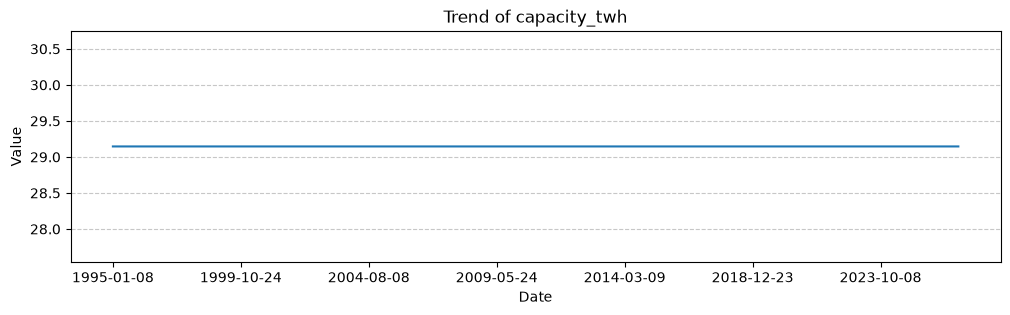

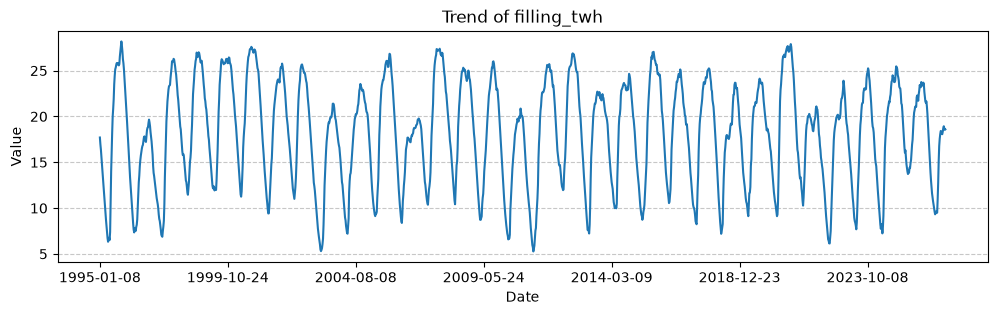

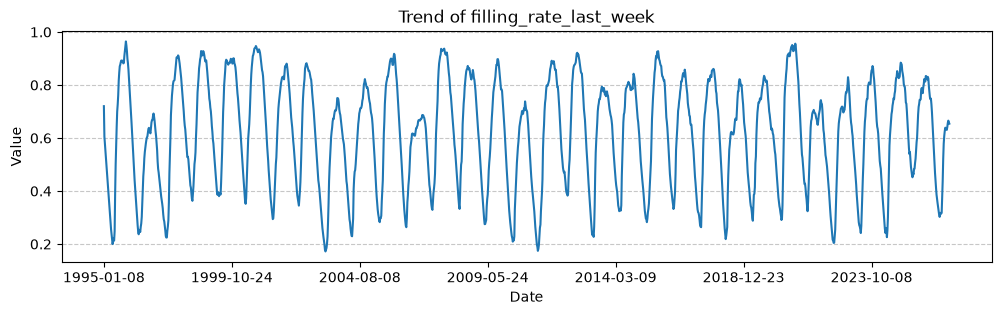

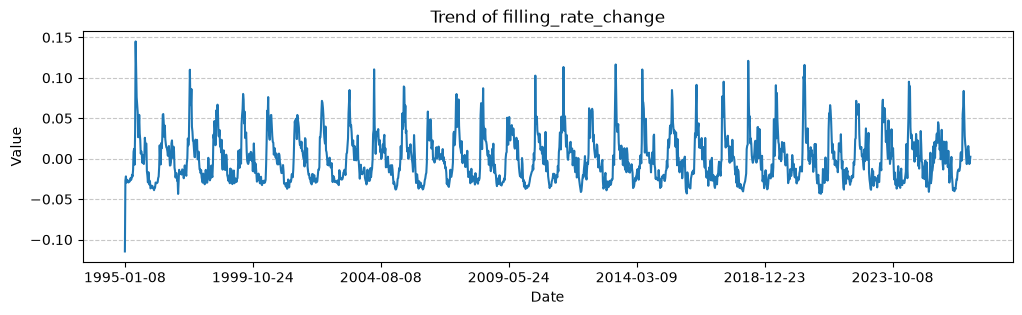

In [9]:
import matplotlib.pyplot as plt

numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns #only numerical columns to avoid plotting non-numerical data otherwise it will throw an error
df_national = df.groupby('date')[numeric_columns].mean() #new dataframe with the national average of the numerical columns for each date

for col in numeric_columns: 
    plt.figure(figsize=(12, 3))
    df_national[col].plot(linewidth=1.5, color='#1f77b4')
    plt.title(f"Trend of {col}")
    plt.ylabel("Value")
    plt.xlabel("Date")
    plt.grid(axis='y', linestyle='--', alpha=0.7) #adds horizontal grid lines to read values easier
    plt.show()

    

### Plot all columns together. Consider how to make this natural, given that the scales are different.
To visualize all metrics on a single chart naturally, I had to consider the vastly different scales (e.g., total capacity in TWh vs. filling rate in percentages). I apply a **Min-Max Normalization** to rescale all physical metrics to a proportional 0.0 - 1.0 range, allowing for a direct visual comparison of their trends. Structural columns like `year` and `week` are intentionally excluded to focus solely on the physical reservoir dynamics.

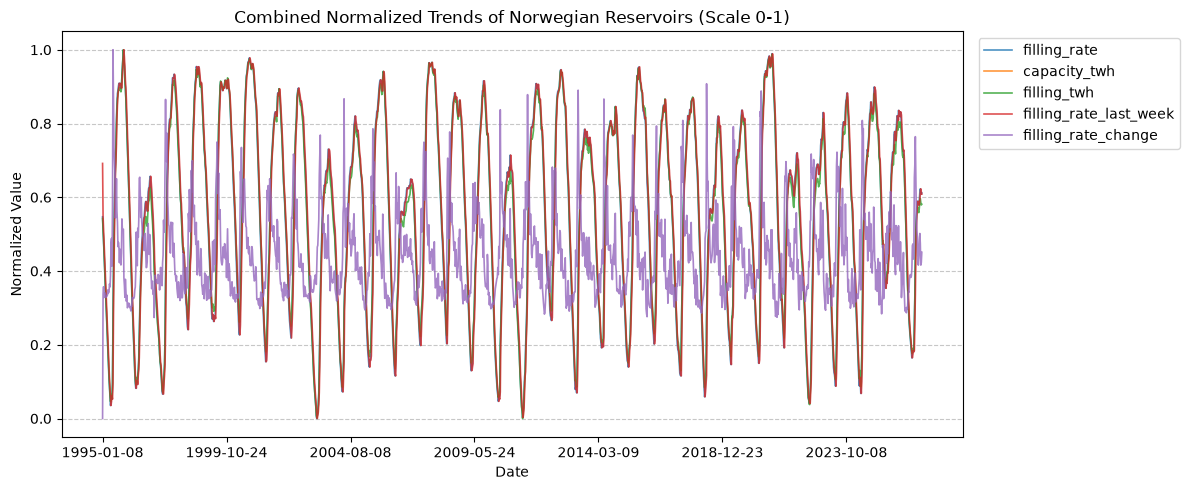

In [10]:
cols_to_drop = ['year', 'week', 'area_number'] # Isolate only the relevant physical metrics, dropping structural columns like year or week
metrics_df = df_national.drop(columns=cols_to_drop, errors='ignore')

df_normalized = (metrics_df - metrics_df.min()) / (metrics_df.max() - metrics_df.min()) #min-max normalization formula applied to each column
#now I have a new dataframe with all the columns normalized between 0 and 1

plt.figure(figsize=(12, 5)) #here I create a new figure with a specific size to accommodate the combined plot of all normalized metrics
df_normalized.plot(ax=plt.gca(), linewidth=1.2, alpha=0.8)

plt.title("Combined Normalized Trends of Norwegian Reservoirs (Scale 0-1)")
plt.ylabel("Normalized Value")
plt.xlabel("Date")

plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left') #i created an external legend to be able to read all the metrics without overlapping the plot
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout() #avoid overlapping of the plot with the legend and other elements
plt.show()

# Streamlit app

The following sections document the source code for the interactive Streamlit web application. The dashboard is structured as a multi-page app, applying core deployment concepts such as data caching, interactive widgets, and spatial layout management.

5.1 Main Application (`app.py`)
This file serves as the entry point, setting up the global page configuration and applying a custom UI style to hide default Streamlit branding for a more professional look.

In [ ]:
#app.py
import streamlit as st

st.set_page_config(page_title="Reservoirs App", page_icon="💧")

st.title("Home Page: Norwegian Reservoirs")
st.write("Welcome to the dashboard. Please use the sidebar to navigate through the data sections.")



### (`pages/2_Table.py`)
This page handles the raw data display. It implements the `@st.cache_data` decorator to store the dataset in memory, preventing redundant disk reads and ensuring the application remains highly responsive.

In [ ]:
#Table.py
import streamlit as st
import pandas as pd

@st.cache_data
def load_and_clean_data():
    # Read the local CSV file
    df = pd.read_csv(r"C:\Users\matti\Desktop\ind320-m4tti4fr4nchi\data\reservoirs.csv")
    
    # Rename columns using the same dictionary from the Jupyter Notebook
    translation_dict = {
        'dato_Id': 'date', 'omrType': 'area_type', 'omrnr': 'area_number',
        'iso_aar': 'year', 'iso_uke': 'week', 'fyllingsgrad': 'filling_rate',
        'kapasitet_TWh': 'capacity_twh', 'fylling_TWh': 'filling_twh',
        'neste_Publiseringsdato': 'next_publish_date',
        'fyllingsgrad_forrige_uke': 'filling_rate_last_week',
        'endring_fyllingsgrad': 'filling_rate_change'
    }
    df = df.rename(columns=translation_dict)
    df['date'] = pd.to_datetime(df['date'])
    
    return df

st.title("Imported Data Overview")

df = load_and_clean_data()

# Isolate the first month of the data series based on the earliest dates available
first_month_df = df[df['date'] < '1995-02-01']

# I did not want to include categorical text columns in the chart, so I filtered for purely numerical columns
numeric_columns = ["filling_rate", "capacity_twh", "filling_twh", "filling_rate_last_week", "filling_rate_change"] 
    # i tried to filter the columns to only include the numeric ones, but it was not working properly, so I manually selected the numeric columns instead.

# Restructure the data: each original column becomes a row containing a list of its values
table_data = {
    "Metric Name": numeric_columns,
    "First Month Trend": [first_month_df[col].tolist() for col in numeric_columns]
}
df_chart = pd.DataFrame(table_data)

# Render the dataframe configuring the trend column to display as an inline sparkline chart
st.dataframe(
    df_chart,
    column_config={
        "First Month Trend": st.column_config.LineChartColumn(
            "First Month Trend (Jan 1995)"
        )
    },
    hide_index=True,
    use_container_width=True
)

###  (`pages/3_Plot.py`)
This module transitions from static reporting to dynamic exploration. Using `st.multiselect`, users can isolate and compare specific numerical metrics over time.

In [ ]:
import streamlit as st

...

df = load_and_clean_data()

numeric_columns = ['filling_rate', 'capacity_twh', 'filling_twh', 'filling_rate_last_week', 'filling_rate_change']

# Aggregate data by date to create a clean national average (just like we did in Jupyter)
df_national = df.groupby('date')[numeric_columns].mean()

# I create an interactive multi-select box for the user
selected_metrics = st.multiselect("Select one or more metrics to plot:", options=numeric_columns,
)

min_date = df["date"].min()
max_date = df["date"].max()

start_date, end_date = st.slider(
    "Select a date range to zoom in on the chart:",
    min_value=min_date.to_pydatetime(),
    max_value=max_date.to_pydatetime(),
    value=(min_date.to_pydatetime(), max_date.to_pydatetime()),
    format="MM-YYYY"
)

df_window = df[(df["date"] >= pd.Timestamp(start_date)) & (df["date"] <= pd.Timestamp(end_date))].copy()
df_national = df_window.groupby("date")[numeric_columns].mean()

if selected_metrics:
    st.line_chart(df_national[selected_metrics])
else:
    st.warning("Please select at least one metric from the dropdown menu above and a date range.") 
    # now i create a line chart based on the selected metrics. If no metrics are selected, I display a warning message.

### (`pages/4_Extra.py`)
This page breaks the standard vertical flow by utilizing `st.columns(5)` to create a horizontal grid of Key Performance Indicators (KPIs). It features a dynamic `st.selectbox` to filter geographical data, ensuring strict comparison between equivalent physical areas (e.g., 'EL' price areas).

In [ ]:
# 4_Extra.
import streamlit as st

...

st.title("Extra: Regional Dashboard")
st.write("A cross-sectional comparison of the 5 Norwegian price areas for the most recent date available.")

df = load_and_clean_data()

#I took the latest date from the dataset and displayed it as a subheader to indicate the snapshot status of the data being presented.
latest_date = df['date'].max()
st.subheader(f"Snapshot status for: {latest_date.strftime('%Y-%m-%d')}")

#Extract all available area types and create a dropdown menu for the user
available_types = df['area_type'].unique()
selected_type = st.selectbox(
    "Select Geographical Grouping:", 
    options=available_types, 
    index=list(available_types).index('EL') 
)

#From the user selection, I filter the dataframe to show only the latest date and the selected area type. I then sort the data by area number to ensure a consistent display order.
latest_data = df[(df['date'] == latest_date) & (df['area_type'] == selected_type)].copy()
latest_data = latest_data.sort_values('area_number')

#I created a 5-column layout to display the metrics for each area side by side, with the filing rate and the change from the previous week. I use a loop to iterate through the rows of the filtered dataframe and display each metric in its respective column.
cols = st.columns(5)
for i, row in enumerate(latest_data.itertuples()):
    with cols[i % 5]:
        area_name = f"Area {row.area_number}"
        current_rate = row.filling_rate * 100
        change = row.filling_rate_change * 100
        st.metric(label=area_name, value=f"{current_rate:.1f}%", delta=f"{change:.2f}%")

